In [1]:
import pandas as pd

columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

df = pd.read_csv("pima-indians-diabetes.csv", header=None, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
import numpy as np

cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)

In [4]:
df.fillna(df.median(), inplace=True)

In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

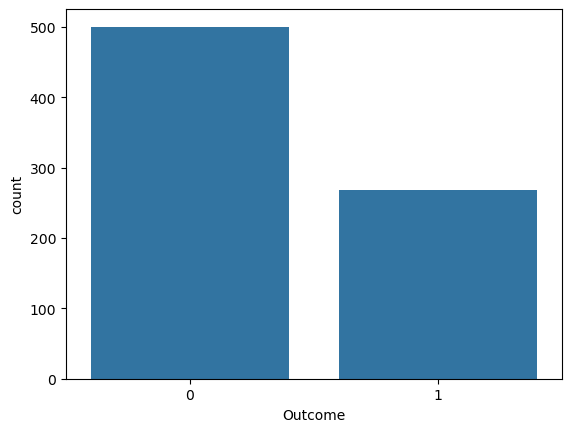

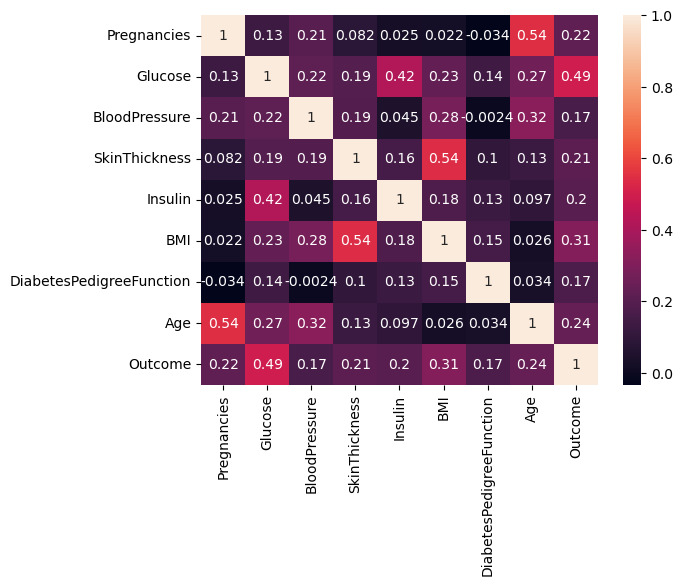

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Outcome', data=df)
plt.show()

sns.heatmap(df.corr(), annot=True)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
from sklearn.metrics import accuracy_score, classification_report

for model in [lr, rf]:
    y_pred = model.predict(X_test)
    print(model.__class__.__name__)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("--------")

LogisticRegression
Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

--------
RandomForestClassifier
Accuracy: 0.7597402597402597
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        99
           1       0.66      0.69      0.67        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154

--------


In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=5)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
import pickle

pickle.dump(rf, open('diabetes_model.pkl', 'wb'))

In [15]:
results = []

for model in [lr, rf]:
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((model.__class__.__name__, acc))

for name, acc in results:
    print(f"{name}: {acc}")

LogisticRegression: 0.7532467532467533
RandomForestClassifier: 0.7467532467532467


In [16]:
from sklearn.metrics import recall_score

print("Recall:", recall_score(y_test, y_pred))

Recall: 0.6181818181818182


<Axes: >

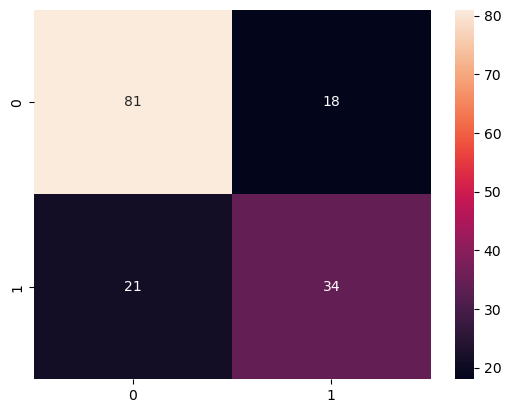

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

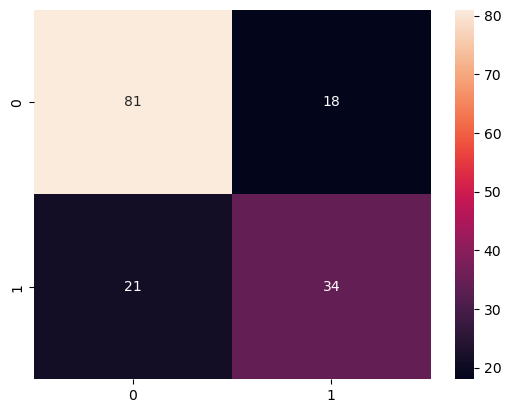

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

In [19]:
import pickle
pickle.dump(rf, open('final_model.pkl', 'wb'))

In [20]:
y_pred = rf.predict(X_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.7467532467532467


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7597402597402597


In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))

LR Accuracy: 0.7532467532467533


In [24]:
from sklearn.metrics import recall_score

print("Recall:", recall_score(y_test, y_pred))

Recall: 0.6727272727272727


In [43]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
   
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(name)
    print("CV Accuracy:", scores.mean())
    print("--------")

Logistic Regression
CV Accuracy: 0.7474662592309651
--------
Random Forest
CV Accuracy: 0.7605042016806723
--------


In [25]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
print(feature_importance.sort_values(ascending=False))

Glucose                     0.296324
BMI                         0.168435
Age                         0.146417
DiabetesPedigreeFunction    0.101371
Insulin                     0.100419
SkinThickness               0.063464
BloodPressure               0.062385
Pregnancies                 0.061186
dtype: float64


In [26]:
import pandas as pd
import numpy as np

columns = [
    'Pregnancies','Glucose','BloodPressure','SkinThickness',
    'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome'
]

df = pd.read_csv("pima-indians-diabetes.csv", header=None, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols] = df[cols].replace(0, np.nan)

df.fillna(df.median(), inplace=True)

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [28]:
X = df[['Glucose', 'BMI', 'Age', 'Pregnancies']]
y = df['Outcome']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'gini'
,max_depth,10
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [34]:
from sklearn.metrics import accuracy_score, recall_score, classification_report

# Logistic Regression
y_pred_lr = lr.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))

# Random Forest
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# SVM
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Accuracy: 0.7662337662337663
Random Forest Accuracy: 0.7532467532467533
SVM Accuracy: 0.7467532467532467


In [35]:
print("RF Recall:", recall_score(y_test, y_pred_rf))

RF Recall: 0.6909090909090909


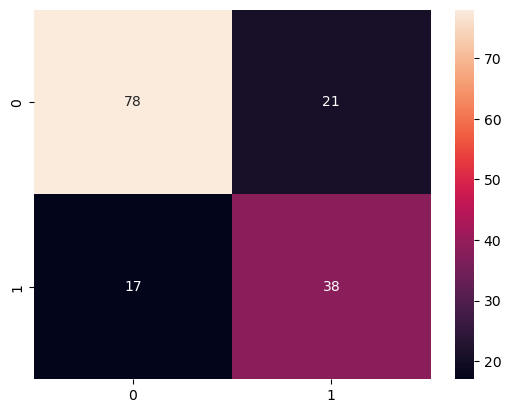

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True)
plt.show()

In [37]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Glucose        0.422561
BMI            0.256091
Age            0.224181
Pregnancies    0.097168
dtype: float64


In [38]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Glucose        0.422561
BMI            0.256091
Age            0.224181
Pregnancies    0.097168
dtype: float64


In [39]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

Glucose        0.422561
BMI            0.256091
Age            0.224181
Pregnancies    0.097168
dtype: float64


In [40]:
import pickle

pickle.dump(rf, open('final_model.pkl', 'wb'))

In [42]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(name)
    print("CV Accuracy:", scores.mean())
    print("--------")

Logistic Regression
CV Accuracy: 0.7474662592309651
--------
Random Forest
CV Accuracy: 0.7605042016806723
--------
SVM
CV Accuracy: 0.7656650539003479
--------
